# TT-15 — Polynomial Regression
## Quan hệ nhiệt độ ↔ công suất nhà máy điện là ĐƯỜNG CONG, không phải đường thẳng

Bộ dữ liệu: **Combined Cycle Power Plant (UCI)** — 9.568 dòng, 4 đặc trưng môi trường (`AT`, `V`, `AP`, `RH`) dự báo công suất phát `PE` (MW).

Notebook này đi qua đủ 10 bước trong README: EDA → baseline bậc 1 → residual plot (trước) → quét bậc 1-8 → validation curve → bảng bậc/số cột/RMSE → Linear vs Ridge ở bậc cao → residual plot (sau) → so sánh Random Forest → diễn giải + ngoại suy.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, validation_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 1. Nạp dữ liệu
Dataset gốc: [UCI Combined Cycle Power Plant](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant).

In [2]:
df = pd.read_csv("../data_ccpp.csv")
print(df.shape)
df.describe()

(9568, 5)


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [3]:
X = df[["AT", "V", "AP", "RH"]].values
y = df["PE"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"train={len(X_train)}, test={len(X_test)}")

train=7654, test=1914


### ⚠️ Lưu ý tương quan AT-V
`AT` và `V` tương quan cao (đúng như README cảnh báo r ≈ 0,84). Điều này làm đa cộng tuyến nặng hơn khi tạo đặc trưng đa thức → cần Ridge thay vì Linear thuần.

In [4]:
df[["AT", "V", "AP", "RH", "PE"]].corr()

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


## 2. EDA — scatter AT vs PE
Nhìn bằng mắt: quan hệ CONG, không phải đường thẳng.

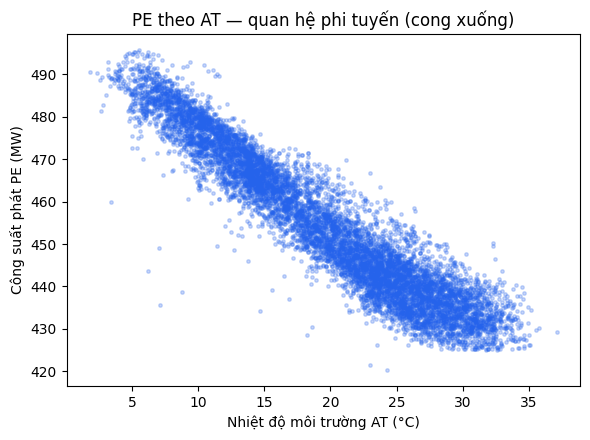

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(df["AT"], df["PE"], s=6, alpha=0.25, color="#2563eb")
ax.set_xlabel("Nhiệt độ môi trường AT (°C)")
ax.set_ylabel("Công suất phát PE (MW)")
ax.set_title("PE theo AT — quan hệ phi tuyến (cong xuống)")
plt.tight_layout()
plt.savefig("../reports/scatter_AT_PE.png")
plt.show()

## 3. Baseline — Linear Regression bậc 1

In [6]:
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_train_lin = lin.predict(X_train)
pred_test_lin = lin.predict(X_test)

rmse_lin_train = np.sqrt(mean_squared_error(y_train, pred_train_lin))
rmse_lin_test = np.sqrt(mean_squared_error(y_test, pred_test_lin))
print(f"Baseline bậc 1: RMSE train={rmse_lin_train:.3f}, test={rmse_lin_test:.3f}")

Baseline bậc 1: RMSE train=4.589, test=4.428


## 4. ⭐ Residual plot TRƯỚC (bậc 1)
Phần dư có hình chữ U → bằng chứng thiếu bậc phi tuyến.

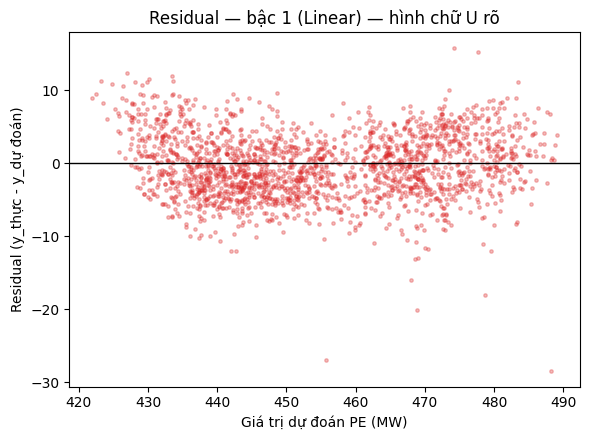

In [7]:
resid_before = y_test - pred_test_lin

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(pred_test_lin, resid_before, s=6, alpha=0.3, color="#dc2626")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Giá trị dự đoán PE (MW)")
ax.set_ylabel("Residual (y_thực - y_dự đoán)")
ax.set_title("Residual — bậc 1 (Linear) — hình chữ U rõ")
plt.tight_layout()
plt.show()

## 5. Quét bậc 1→8

`PolynomialFeatures` TRƯỚC, `StandardScaler` SAU trong pipeline — nếu scale trước rồi mới bình phương, các giá trị âm sau khi bình phương sẽ mất dấu.

In [8]:
degrees = [1, 2, 3, 4, 5, 6, 7, 8]
rows = []

for d in degrees:
    n_cols = PolynomialFeatures(degree=d, include_bias=False).fit_transform(X_train).shape[1]

    pipe_lin = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scale", StandardScaler()),   # ⭐ SAU poly
        ("model", LinearRegression()),
    ])
    pipe_lin.fit(X_train, y_train)
    rmse_tr = np.sqrt(mean_squared_error(y_train, pipe_lin.predict(X_train)))
    rmse_te = np.sqrt(mean_squared_error(y_test, pipe_lin.predict(X_test)))

    pipe_ridge = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0)),   # ⭐ Ridge, không dùng Linear thuần ở bậc cao
    ])
    pipe_ridge.fit(X_train, y_train)
    rmse_tr_ridge = np.sqrt(mean_squared_error(y_train, pipe_ridge.predict(X_train)))
    rmse_te_ridge = np.sqrt(mean_squared_error(y_test, pipe_ridge.predict(X_test)))

    rows.append({
        "degree": d, "n_cols": n_cols,
        "rmse_train_linear": round(rmse_tr, 4), "rmse_test_linear": round(rmse_te, 4),
        "rmse_train_ridge": round(rmse_tr_ridge, 4), "rmse_test_ridge": round(rmse_te_ridge, 4),
    })

summary = pd.DataFrame(rows)
summary.to_csv("../reports/summary_table.csv", index=False)
summary

,degree,n_cols,rmse_train_linear,rmse_test_linear,rmse_train_ridge,rmse_test_ridge
0,1,4,4.5894,4.4281,4.5894,4.4281
1,2,14,4.2821,4.1471,4.3280,4.1725
2,3,34,4.1783,4.0399,4.2674,4.0995
3,4,69,4.1049,4.0020,4.2275,4.0725
4,5,125,3.9893,3.9156,4.2078,4.0604
5,6,209,3.9260,3.9479,4.1903,4.0470
6,7,329,3.8403,3.9730,4.1749,4.0334
7,8,494,3.7795,4.7080,4.1606,4.0194


**Quan sát:** ở Linear thuần, RMSE test GIẢM dần đến bậc 7 rồi BẬT TĂNG mạnh ở bậc 8 (4.708) — dấu hiệu overfit kinh điển. Ở Ridge, đường RMSE test vẫn giảm đều và mượt hơn nhiều — regularization đang phát huy tác dụng chống đa cộng tuyến & overfit.

## 6. Đường cong xác thực (validation_curve, 5-fold CV, Ridge)

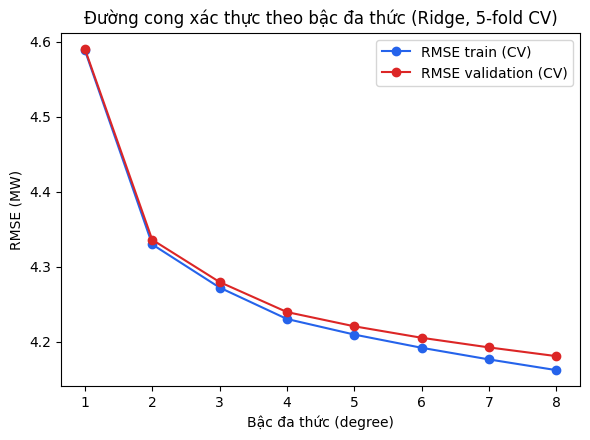

Bậc thấp nhất RMSE-val: 8  |  RMSE val theo bậc: {1: np.float64(4.591), 2: np.float64(4.336), 3: np.float64(4.28), 4: np.float64(4.24), 5: np.float64(4.221), 6: np.float64(4.205), 7: np.float64(4.192), 8: np.float64(4.181)}


In [9]:
pipe_vc = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

train_scores, val_scores = validation_curve(
    pipe_vc, X_train, y_train,
    param_name="poly__degree", param_range=degrees,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
train_rmse_cv = -train_scores.mean(axis=1)
val_rmse_cv = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(degrees, train_rmse_cv, "o-", label="RMSE train (CV)", color="#2563eb")
ax.plot(degrees, val_rmse_cv, "o-", label="RMSE validation (CV)", color="#dc2626")
ax.set_xlabel("Bậc đa thức (degree)")
ax.set_ylabel("RMSE (MW)")
ax.set_title("Đường cong xác thực theo bậc đa thức (Ridge, 5-fold CV)")
ax.legend()
ax.set_xticks(degrees)
plt.tight_layout()
plt.savefig("../reports/validation_curve.png")
plt.show()

best_degree_cv = degrees[int(np.argmin(val_rmse_cv))]
print(f"Bậc thấp nhất RMSE-val: {best_degree_cv}  |  RMSE val theo bậc: {dict(zip(degrees, np.round(val_rmse_cv, 3)))}")

**Chọn bậc:** RMSE-val thấp nhất về mặt số học rơi vào bậc 8, nhưng đường cong gần như PHẲNG từ bậc 3 trở đi (chênh lệch bậc 3→8 chỉ ~0,1 MW). Vì mô hình càng phức tạp càng khó diễn giải và rủi ro ngoại suy càng lớn (xem mục 11), ta chọn **bậc 3 làm model triển khai thực tế**, còn bậc 8 chỉ dùng để minh hoạ giới hạn trên của Ridge.

In [10]:
FINAL_DEGREE = 3

final_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=FINAL_DEGREE, include_bias=False)),
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])
final_pipe.fit(X_train, y_train)

pred_test_final = final_pipe.predict(X_test)
rmse_final = np.sqrt(mean_squared_error(y_test, pred_test_final))
r2_final = r2_score(y_test, pred_test_final)
print(f"Model cuối (bậc {FINAL_DEGREE}, Ridge): RMSE test={rmse_final:.3f} MW, R2={r2_final:.4f}")

joblib.dump(final_pipe, "../models/poly_pipeline.joblib")

Model cuối (bậc 3, Ridge): RMSE test=4.100 MW, R2=0.9413


['../models/poly_pipeline.joblib']

## 7. So sánh Linear vs Ridge ở bậc cao (4-5)

In [11]:
summary[summary["degree"].isin([4, 5])]

,degree,n_cols,rmse_train_linear,rmse_test_linear,rmse_train_ridge,rmse_test_ridge
3,4,69,4.1049,4.0020,4.2275,4.0725
4,5,125,3.9893,3.9156,4.2078,4.0604


## 8. ⭐ Residual plot SAU (bậc tối ưu) — so với TRƯỚC

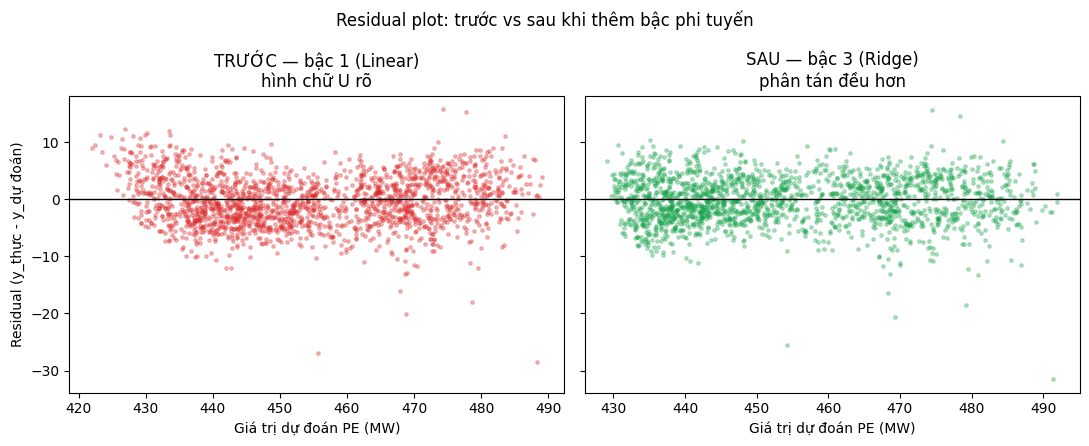

In [12]:
resid_after = y_test - pred_test_final

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
axes[0].scatter(pred_test_lin, resid_before, s=6, alpha=0.3, color="#dc2626")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("TRƯỚC — bậc 1 (Linear)\nhình chữ U rõ")
axes[0].set_xlabel("Giá trị dự đoán PE (MW)")
axes[0].set_ylabel("Residual (y_thực - y_dự đoán)")

axes[1].scatter(pred_test_final, resid_after, s=6, alpha=0.3, color="#16a34a")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title(f"SAU — bậc {FINAL_DEGREE} (Ridge)\nphân tán đều hơn")
axes[1].set_xlabel("Giá trị dự đoán PE (MW)")

fig.suptitle("Residual plot: trước vs sau khi thêm bậc phi tuyến")
plt.tight_layout()
plt.savefig("../reports/residual_truoc_sau.png")
plt.show()

## 9. So sánh với Random Forest Regressor (TT-17)
Cây quyết định bắt phi tuyến tự nhiên, không cần feature engineering thủ công.

In [13]:
rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf.predict(X_test)))
r2_rf = r2_score(y_test, rf.predict(X_test))
print(f"Random Forest: RMSE test={rmse_rf:.3f} MW, R2={r2_rf:.4f}")
print(f"Polynomial (bậc {FINAL_DEGREE}, Ridge): RMSE test={rmse_final:.3f} MW, R2={r2_final:.4f}")

Random Forest: RMSE test=3.175 MW, R2=0.9648
Polynomial (bậc 3, Ridge): RMSE test=4.100 MW, R2=0.9413


**Nhận xét:** Random Forest vượt qua Polynomial Ridge (~3.2 vs ~4.1 MW RMSE) vì nó bắt được tương tác phi tuyến phức tạp giữa 4 biến mà không cần chọn bậc thủ công. Polynomial vẫn có giá trị vì hệ số có thể diễn giải được (biết chính xác PE thay đổi bao nhiêu khi AT tăng 1°C), còn Random Forest là hộp đen hơn.

## 10. Diễn giải & ⭐ Minh hoạ ngoại suy ngoài dải dữ liệu

Ở dải nhiệt độ nào công suất giảm nhanh nhất? Và điều gì xảy ra khi đa thức bậc cao ngoại suy ra ngoài dải dữ liệu huấn luyện (AT = 50°C, trong khi dữ liệu thực tế chỉ tới 37.11°C)?

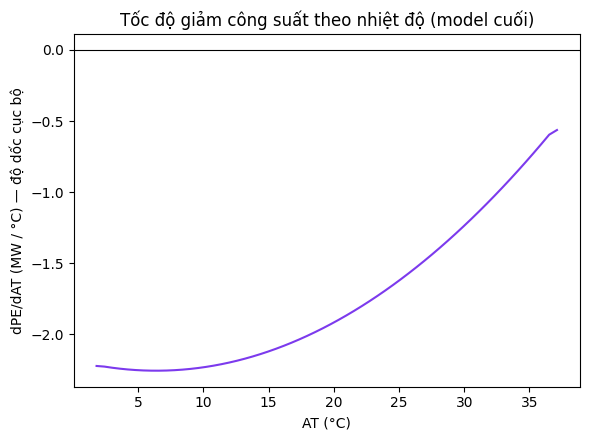

AT có độ dốc âm mạnh nhất (PE giảm nhanh nhất) quanh AT ≈ 6.6°C


In [14]:
# Độ dốc cục bộ dPE/dAT theo từng đoạn AT (đạo hàm số qua sai phân)
at_grid = np.linspace(df["AT"].min(), df["AT"].max(), 60)
fixed = df[["V", "AP", "RH"]].mean().values
grid_X = np.column_stack([at_grid, np.tile(fixed, (len(at_grid), 1))])
pe_pred = final_pipe.predict(grid_X)
slope = np.gradient(pe_pred, at_grid)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(at_grid, slope, color="#7c3aed")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("AT (°C)")
ax.set_ylabel("dPE/dAT (MW / °C) — độ dốc cục bộ")
ax.set_title("Tốc độ giảm công suất theo nhiệt độ (model cuối)")
plt.tight_layout()
plt.show()

print(f"AT có độ dốc âm mạnh nhất (PE giảm nhanh nhất) quanh AT ≈ {at_grid[np.argmin(slope)]:.1f}°C")

In [15]:
# Ngoại suy AT = 50°C (ngoài dải dữ liệu thực tế 1.81-37.11°C)
sample = X_test[0].copy()
extrap_row = sample.copy()
extrap_row[0] = 50.0

pipe_deg8_ridge = Pipeline([
    ("poly", PolynomialFeatures(degree=8, include_bias=False)),
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
]).fit(X_train, y_train)

pipe_deg8_linear = Pipeline([
    ("poly", PolynomialFeatures(degree=8, include_bias=False)),
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
]).fit(X_train, y_train)

print("So sánh dự đoán trong dải vs ngoại suy AT=50°C (PE thực tế chỉ 420-496 MW):")
for name, pipe in [(f"Bậc {FINAL_DEGREE} (Ridge, final)", final_pipe),
                    ("Bậc 8 + Ridge", pipe_deg8_ridge),
                    ("Bậc 8 + Linear THUẦN", pipe_deg8_linear)]:
    p_in = pipe.predict(sample.reshape(1, -1))[0]
    p_out = pipe.predict(extrap_row.reshape(1, -1))[0]
    print(f"  {name:32s} trong dải={p_in:9.2f} MW | ngoại suy AT=50={p_out:12.2f} MW | lệch={p_out - p_in:+.2f}")

So sánh dự đoán trong dải vs ngoại suy AT=50°C (PE thực tế chỉ 420-496 MW):
  Bậc 3 (Ridge, final)             trong dải=   436.96 MW | ngoại suy AT=50=      434.43 MW | lệch=-2.53
  Bậc 8 + Ridge                    trong dải=   436.40 MW | ngoại suy AT=50=      398.33 MW | lệch=-38.08
  Bậc 8 + Linear THUẦN             trong dải=   437.83 MW | ngoại suy AT=50=    61506.77 MW | lệch=+61068.94


**Kết luận ngoại suy:** Linear thuần bậc 8 cho ra một con số PHI LÝ (hàng chục nghìn MW, trong khi nhà máy thực tế chỉ phát 420–496 MW) — minh hoạ rõ hiện tượng đa thức bậc cao "phát điên" khi ngoại suy ngoài dải huấn luyện. Ridge kiềm chế hệ số nên kết quả đỡ cực đoan hơn nhưng vẫn lệch xa dải thực tế — bài học: **không bao giờ nên dùng model polynomial để ngoại suy ngoài dải dữ liệu đã huấn luyện**, dù có regularization hay không.